# Exercice 3 — Qualifier la relation entre incidents et maintenances

## Objectif concret

Ce notebook vérifie si `related_incident_id` représente une relation exploitable entre un incident Bronze et une maintenance. Nous testerons successivement la structure du lien, son ordre temporel, la proximité entre le commentaire de l'incident et le composant remplacé, puis les caractéristiques des machines reliées.

Le résultat attendu est une décision argumentée pour le modèle relationnel Silver : conserver ou non la clé étrangère entre maintenance et incident, sans confondre association statistique et causalité.

## Prérequis et point de départ

- exécuter le notebook depuis la racine du projet `indusense` ;
- disposer de `datas/machine.csv` et `datas/releves_incidents.csv.csv` ;
- utiliser l'environnement Python du projet, qui contient pandas, Matplotlib, SciPy et tabulate.

Les commentaires libres sont lus uniquement pour cette exploration en mémoire. Aucun nom d'opérateur, badge ou commentaire n'est exporté vers Silver.

In [1]:
from hashlib import sha256
from pathlib import Path
import random
import re
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import fisher_exact, mannwhitneyu, pearsonr, spearmanr
from tabulate import tabulate


CHEMIN_MAINTENANCES = Path("datas") / "machine.csv"
CHEMIN_INCIDENTS = Path("datas") / "releves_incidents.csv.csv"
GRAINE_ALEATOIRE = 20260901
NOMBRE_PERMUTATIONS = 20_000


def empreinte_sha256(chemin):
    # L'empreinte permet de vérifier que l'exploration ne modifie pas le Bronze.
    return sha256(chemin.read_bytes()).hexdigest()


empreintes_avant = {
    CHEMIN_MAINTENANCES: empreinte_sha256(CHEMIN_MAINTENANCES),
    CHEMIN_INCIDENTS: empreinte_sha256(CHEMIN_INCIDENTS),
}

print("Fichiers Bronze trouvés et empreintes initiales calculées.")

Fichiers Bronze trouvés et empreintes initiales calculées.


## 1. Charger les sources et construire les 25 liens déclarés

Le fichier `machine.csv` possède un grain mixte : une ligne décrit à la fois une machine et une intervention de maintenance. Le fichier d'incidents possède une ligne par incident.

Nous conservons les chaînes vides pendant la lecture afin de distinguer une maintenance sans incident lié. Les dates sont converties en UTC uniquement dans les copies en mémoire. La jointure utilise `related_incident_id` vers `incident_id` et exige qu'un identifiant retrouve au plus une ligne d'incident.

Le résultat visible attendu est un profil compact des deux sources et du nombre de relations retrouvées.

In [2]:
maintenances = pd.read_csv(
    CHEMIN_MAINTENANCES,
    dtype=str,
    keep_default_na=False,
)
incidents = pd.read_csv(
    CHEMIN_INCIDENTS,
    dtype=str,
    keep_default_na=False,
)

maintenances["maintenance_at_utc"] = pd.to_datetime(
    maintenances["maintenance_at"],
    errors="raise",
    utc=True,
)
incidents["incident_at_utc"] = pd.to_datetime(
    incidents["date"] + " " + incidents["time"],
    errors="raise",
    utc=True,
)
maintenances["has_related_incident"] = maintenances["related_incident_id"].ne("")

liens = maintenances.loc[maintenances["has_related_incident"]].merge(
    incidents,
    left_on="related_incident_id",
    right_on="incident_id",
    how="left",
    suffixes=("_maintenance", "_incident"),
    validate="one_to_one",
)

colonnes_types = [colonne for colonne in incidents.columns if colonne.startswith("type_")]
liens["incident_type"] = liens[colonnes_types].apply(
    lambda ligne: next(
        (colonne.removeprefix("type_") for colonne in colonnes_types if ligne[colonne] == "1"),
        "aucun_type",
    ),
    axis=1,
)
liens["lag_days"] = (
    liens["maintenance_at_utc"] - liens["incident_at_utc"]
).dt.total_seconds() / 86_400

profil = pd.DataFrame(
    {
        "Contrôle": [
            "Lignes machine-maintenance",
            "Lignes incident",
            "Maintenances avec incident lié",
            "Identifiants liés retrouvés",
            "Liens portant sur la même machine",
        ],
        "Valeur": [
            len(maintenances),
            len(incidents),
            int(maintenances["has_related_incident"].sum()),
            int(liens["incident_id"].notna().sum()),
            int(liens["machine_code"].eq(liens["machine_id"]).sum()),
        ],
    }
)

print(tabulate(profil, headers="keys", tablefmt="rounded_outline", showindex=False))

╭───────────────────────────────────┬──────────╮
│ Contrôle                          │   Valeur │
├───────────────────────────────────┼──────────┤
│ Lignes machine-maintenance        │      115 │
│ Lignes incident                   │     1245 │
│ Maintenances avec incident lié    │       25 │
│ Identifiants liés retrouvés       │       25 │
│ Liens portant sur la même machine │        1 │
╰───────────────────────────────────┴──────────╯


## 2. Tester l'association entre maintenance réactive et présence du lien

Une **table de contingence** croise les effectifs de deux variables catégorielles. Ici, elle compare le type de maintenance et la présence de `related_incident_id`.

Le **test exact de Fisher** évalue si cette répartition est compatible avec une indépendance entre les deux variables. Sa valeur `p` n'est pas la probabilité que l'hypothèse soit vraie : elle mesure la rareté d'une association au moins aussi forte si les variables étaient indépendantes.

Le résultat visible attendu est la répartition proactive/réactive et la valeur `p`.

In [3]:
table_presence = pd.crosstab(
    maintenances["maintenance_type"],
    maintenances["has_related_incident"],
).reindex(
    index=["proactive", "reactive"],
    columns=[False, True],
    fill_value=0,
)
table_presence.columns = ["Sans lien", "Avec lien"]

resultat_fisher = fisher_exact(table_presence.to_numpy())

print(tabulate(table_presence, headers="keys", tablefmt="rounded_outline"))
print()
print(f"Test exact de Fisher : p = {resultat_fisher.pvalue:.3e}")
print(
    "Interprétation : le lien est systématique pour les maintenances réactives "
    "et absent des maintenances proactives."
)

╭────────────────────┬─────────────┬─────────────╮
│ maintenance_type   │   Sans lien │   Avec lien │
├────────────────────┼─────────────┼─────────────┤
│ proactive          │          90 │           0 │
│ reactive           │           0 │          25 │
╰────────────────────┴─────────────┴─────────────╯

Test exact de Fisher : p = 7.878e-26
Interprétation : le lien est systématique pour les maintenances réactives et absent des maintenances proactives.


## 3. Vérifier l'ordre temporel sans conclure trop vite à une causalité

Une corrélation de **Spearman** égale à 1 signifie que les rangs de deux séries suivent exactement le même ordre. Une corrélation de **Pearson** proche de 1 indique ici que leurs dates évoluent presque linéairement ensemble.

Nous calculons aussi le délai entre l'incident référencé et la maintenance. Un lien peut être construit et chronologiquement cohérent sans désigner l'événement déclencheur immédiat.

Le graphique attendu représente le délai en jours pour chaque maintenance réactive. Une croissance régulière du délai doit être signalée comme une structure possible de génération des données.

╭────────────────────────────────────────────┬──────────╮
│ Mesure                                     │   Valeur │
├────────────────────────────────────────────┼──────────┤
│ Incidents liés antérieurs à la maintenance │  25      │
│ Spearman sur les identifiants              │   1      │
│ Spearman sur les dates                     │   1      │
│ Pearson sur les dates                      │   0.9992 │
│ Délai minimal en jours                     │   1.7    │
│ Délai médian en jours                      │  35.7    │
│ Délai maximal en jours                     │ 102.7    │
│ Rang médian de récence                     │ 149      │
│ Spearman ordre-maintenance / délai         │   0.9915 │
╰────────────────────────────────────────────┴──────────╯


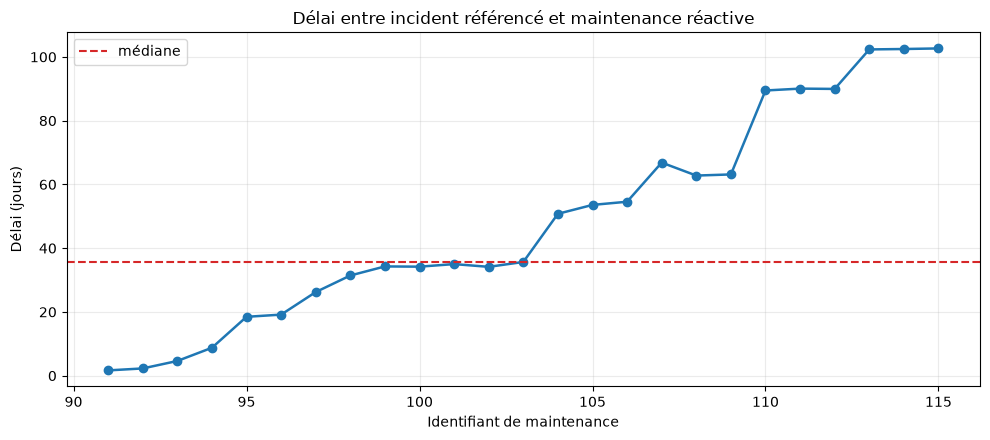

In [4]:
ordre_maintenance = pd.to_numeric(liens["maintenance_id"], errors="raise")
ordre_incident = pd.to_numeric(
    liens["incident_id"].str.removeprefix("INC-"),
    errors="raise",
)
temps_maintenance = liens["maintenance_at_utc"].astype("int64")
temps_incident = liens["incident_at_utc"].astype("int64")

rho_identifiants = spearmanr(ordre_maintenance, ordre_incident).statistic
rho_dates = spearmanr(temps_maintenance, temps_incident).statistic
r_dates = pearsonr(temps_maintenance, temps_incident).statistic
rho_delai = spearmanr(ordre_maintenance, liens["lag_days"]).statistic

rangs_recence = []
for _, lien in liens.iterrows():
    incidents_anterieurs = (
        incidents.loc[incidents["incident_at_utc"] < lien["maintenance_at_utc"]]
        .sort_values("incident_at_utc", ascending=False)
        .reset_index(drop=True)
    )
    rang = int(incidents_anterieurs.index[
        incidents_anterieurs["incident_id"].eq(lien["incident_id"])
    ][0]) + 1
    rangs_recence.append(rang)

rapport_temporel = pd.DataFrame(
    {
        "Mesure": [
            "Incidents liés antérieurs à la maintenance",
            "Spearman sur les identifiants",
            "Spearman sur les dates",
            "Pearson sur les dates",
            "Délai minimal en jours",
            "Délai médian en jours",
            "Délai maximal en jours",
            "Rang médian de récence",
            "Spearman ordre-maintenance / délai",
        ],
        "Valeur": [
            int(liens["lag_days"].gt(0).sum()),
            round(float(rho_identifiants), 4),
            round(float(rho_dates), 4),
            round(float(r_dates), 4),
            round(float(liens["lag_days"].min()), 1),
            round(float(liens["lag_days"].median()), 1),
            round(float(liens["lag_days"].max()), 1),
            float(pd.Series(rangs_recence).median()),
            round(float(rho_delai), 4),
        ],
    }
)
print(tabulate(rapport_temporel, headers="keys", tablefmt="rounded_outline", showindex=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ordre_maintenance, liens["lag_days"], marker="o", linewidth=1.8)
ax.axhline(liens["lag_days"].median(), color="tab:red", linestyle="--", label="médiane")
ax.set_title("Délai entre incident référencé et maintenance réactive")
ax.set_xlabel("Identifiant de maintenance")
ax.set_ylabel("Délai (jours)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Croiser le commentaire de l'incident avec le composant remplacé

Le commentaire est un texte libre Bronze. Il peut préciser le symptôme au-delà des colonnes indicatrices `type_*`, mais il ne doit pas être recopié automatiquement dans Silver.

Nous effectuons deux contrôles :

1. vérifier que la description de maintenance mentionne exactement l'incident lié ;
2. construire une table agrégée composant–type d'incident, sans afficher les noms ou badges des opérateurs.

Le résultat attendu permet d'observer des correspondances plausibles comme température–surchauffe, roulement–bruit ou courroie–vibration.

In [5]:
liens["description_mentions_link"] = liens.apply(
    lambda ligne: ligne["related_incident_id"] in ligne["description"],
    axis=1,
)

table_composant_type = pd.crosstab(
    liens["component"],
    liens["incident_type"],
)

print(
    "Descriptions mentionnant exactement l'incident lié : "
    f"{int(liens['description_mentions_link'].sum())}/{len(liens)}"
)
print()
print("Répartition agrégée composant × type d'incident :")
print(tabulate(table_composant_type, headers="keys", tablefmt="rounded_outline"))

Descriptions mentionnant exactement l'incident lié : 25/25

Répartition agrégée composant × type d'incident :
╭─────────────────────────┬──────────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────┬───────────────────┬─────────────╮
│ component               │   alarme_capteur │   baisse_pression │   bruit_mecanique │   defaut_qualite │   surchauffe │   surconsommation │   vibration │
├─────────────────────────┼──────────────────┼───────────────────┼───────────────────┼──────────────────┼──────────────┼───────────────────┼─────────────┤
│ capteur pression        │                0 │                 1 │                 0 │                1 │            0 │                 2 │           2 │
│ capteur température     │                2 │                 0 │                 2 │                0 │            4 │                 0 │           0 │
│ convoyeur sortie        │                0 │                 0 │                 1 │                0 │          

## 5. Comparer la cohérence sémantique aux appariements aléatoires

Une **permutation** mélange les incidents entre les maintenances tout en conservant les mêmes commentaires, composants et effectifs. Elle fournit une situation de référence : ce que l'on observerait si les couples étaient attribués au hasard.

Deux indicateurs exploratoires sont utilisés :

- une similarité lexicale de Jaccard sur des groupes de trois caractères ;
- une grille prudente de compatibilité entre composants et familles de symptômes.

La grille est explicite pour pouvoir être relue, mais elle n'a pas été validée par le métier. Les valeurs `p` obtenues restent donc exploratoires et ne transforment pas une ressemblance en causalité.

In [6]:
def normaliser_texte(texte):
    # La normalisation retire les accents et la ponctuation uniquement pour comparer les mots.
    sans_accents = "".join(
        caractere
        for caractere in unicodedata.normalize("NFKD", texte.lower())
        if not unicodedata.combining(caractere)
    )
    return " ".join(re.findall(r"[a-z0-9]+", sans_accents))


def trigrammes(texte):
    texte_normalise = normaliser_texte(texte).replace(" ", "_")
    return {
        texte_normalise[position : position + 3]
        for position in range(max(0, len(texte_normalise) - 2))
    }


def similarite_jaccard(texte_gauche, texte_droite):
    gauche = trigrammes(texte_gauche)
    droite = trigrammes(texte_droite)
    union = gauche | droite
    return len(gauche & droite) / len(union) if union else 0.0


compatibilites_attendues = {
    "capteur pression": {"baisse_pression", "alarme_capteur"},
    "capteur temperature": {"surchauffe", "alarme_capteur"},
    "outillage presse": {"defaut_qualite"},
    "variateur vitesse": {"vibration", "surconsommation"},
    "roulement axe principal": {"bruit_mecanique", "vibration"},
    "joint hydraulique": {"baisse_pression", "bruit_mecanique"},
    "courroie moteur": {"vibration", "bruit_mecanique"},
    "relais securite": {"alarme_capteur", "arret_urgence"},
    "convoyeur sortie": {"blocage_mecanique", "bruit_mecanique", "defaut_qualite"},
}


def est_compatible(composant, type_incident):
    return type_incident in compatibilites_attendues.get(
        normaliser_texte(composant),
        set(),
    )


composants = liens["component"].tolist()
commentaires = liens["comment"].tolist()
types_incident = liens["incident_type"].tolist()
nombre_liens = len(liens)

# Les matrices évitent de recalculer les comparaisons pendant chaque permutation.
matrice_similarite = [
    [similarite_jaccard(composant, commentaire) for commentaire in commentaires]
    for composant in composants
]
matrice_compatibilite = [
    [est_compatible(composant, type_incident) for type_incident in types_incident]
    for composant in composants
]

similarite_observee = sum(
    matrice_similarite[index][index] for index in range(nombre_liens)
) / nombre_liens
compatibles_observes = sum(
    matrice_compatibilite[index][index] for index in range(nombre_liens)
)

generateur = random.Random(GRAINE_ALEATOIRE)
similarites_permutees = []
compatibilites_permutees = []
indices = list(range(nombre_liens))

for _ in range(NOMBRE_PERMUTATIONS):
    permutation = generateur.sample(indices, k=nombre_liens)
    similarites_permutees.append(
        sum(
            matrice_similarite[index][permutation[index]]
            for index in indices
        ) / nombre_liens
    )
    compatibilites_permutees.append(
        sum(
            matrice_compatibilite[index][permutation[index]]
            for index in indices
        )
    )

p_similarite = (
    1 + sum(valeur >= similarite_observee for valeur in similarites_permutees)
) / (NOMBRE_PERMUTATIONS + 1)
p_compatibilite = (
    1 + sum(valeur >= compatibles_observes for valeur in compatibilites_permutees)
) / (NOMBRE_PERMUTATIONS + 1)

rapport_semantique = pd.DataFrame(
    {
        "Indicateur": [
            "Similarité lexicale observée",
            "Similarité lexicale moyenne aléatoire",
            "p exploratoire de similarité",
            "Couples compatibles observés",
            "Couples compatibles moyens aléatoires",
            "p exploratoire de compatibilité",
        ],
        "Valeur": [
            round(similarite_observee, 4),
            round(sum(similarites_permutees) / NOMBRE_PERMUTATIONS, 4),
            round(p_similarite, 4),
            compatibles_observes,
            round(sum(compatibilites_permutees) / NOMBRE_PERMUTATIONS, 2),
            round(p_compatibilite, 4),
        ],
    }
)

print(tabulate(rapport_semantique, headers="keys", tablefmt="rounded_outline", showindex=False))

╭───────────────────────────────────────┬──────────╮
│ Indicateur                            │   Valeur │
├───────────────────────────────────────┼──────────┤
│ Similarité lexicale observée          │   0.0837 │
│ Similarité lexicale moyenne aléatoire │   0.0444 │
│ p exploratoire de similarité          │   0.0003 │
│ Couples compatibles observés          │  12      │
│ Couples compatibles moyens aléatoires │   6.68   │
│ p exploratoire de compatibilité       │   0.0103 │
╰───────────────────────────────────────┴──────────╯


## 6. Rechercher une explication inter-machine dans le référentiel

Les 24 relations inter-machine pourraient s'expliquer si les machines partageaient plus souvent un modèle, une ligne de production, un atelier ou une criticité.

Pour chaque attribut, nous comptons les égalités observées puis nous mélangeons les machines des incidents. Une valeur `p` élevée indique que le nombre d'égalités observé n'est pas exceptionnel par rapport au hasard.

Le résultat visible attendu est un tableau comparant le nombre observé, la moyenne aléatoire et la valeur `p` de chaque attribut.

In [7]:
attributs_machine = ["model", "production_line", "location", "criticality"]
referentiel_machine = (
    maintenances[["machine_code", *attributs_machine]]
    .drop_duplicates("machine_code")
    .set_index("machine_code")
)

for attribut in attributs_machine:
    liens[f"maintenance_{attribut}"] = liens["machine_code"].map(
        referentiel_machine[attribut]
    )
    liens[f"incident_{attribut}"] = liens["machine_id"].map(
        referentiel_machine[attribut]
    )

generateur_attributs = random.Random(GRAINE_ALEATOIRE)
resultats_attributs = []

for attribut in attributs_machine:
    valeurs_maintenance = liens[f"maintenance_{attribut}"].tolist()
    valeurs_incident = liens[f"incident_{attribut}"].tolist()
    egalites_observees = sum(
        gauche == droite
        for gauche, droite in zip(valeurs_maintenance, valeurs_incident)
    )
    egalites_permutees = []

    for _ in range(NOMBRE_PERMUTATIONS):
        valeurs_melangees = generateur_attributs.sample(
            valeurs_incident,
            k=nombre_liens,
        )
        egalites_permutees.append(
            sum(
                gauche == droite
                for gauche, droite in zip(valeurs_maintenance, valeurs_melangees)
            )
        )

    p_attribut = (
        1 + sum(valeur >= egalites_observees for valeur in egalites_permutees)
    ) / (NOMBRE_PERMUTATIONS + 1)
    resultats_attributs.append(
        {
            "Attribut": attribut,
            "Égalités observées": egalites_observees,
            "Moyenne aléatoire": round(
                sum(egalites_permutees) / NOMBRE_PERMUTATIONS,
                2,
            ),
            "p exploratoire": round(p_attribut, 4),
        }
    )

rapport_attributs = pd.DataFrame(resultats_attributs)
print(tabulate(rapport_attributs, headers="keys", tablefmt="rounded_outline", showindex=False))

╭─────────────────┬──────────────────────┬─────────────────────┬──────────────────╮
│ Attribut        │   Égalités observées │   Moyenne aléatoire │   p exploratoire │
├─────────────────┼──────────────────────┼─────────────────────┼──────────────────┤
│ model           │                    9 │                9.26 │           0.6413 │
│ production_line │                   10 │                8.79 │           0.3726 │
│ location        │                    7 │                8.9  │           0.8436 │
│ criticality     │                    7 │                9.63 │           0.9245 │
╰─────────────────┴──────────────────────┴─────────────────────┴──────────────────╯


## 7. Traduire les observations en décision de modèle Silver

Les faits convergent vers une relation intentionnelle : le lien est réservé aux maintenances réactives, les descriptions citent exactement l'incident et les couples commentaire–composant sont plus cohérents que des couples aléatoires.

La causalité précise reste toutefois non démontrée. Les incidents sont souvent éloignés dans le temps, concernent presque toujours une autre machine et ne partagent pas particulièrement ligne, atelier, modèle ou criticité.

La décision de persistance est donc de conserver une clé étrangère simple et nullable :

```text
silver.maintenance.related_incident_id
    → silver.incident.incident_id
```

La base garantit que l'incident existe. Elle n'impose pas que les deux événements concernent la même machine et ne transforme pas le lien en preuve de causalité.

In [8]:
synthese = pd.DataFrame(
    {
        "Observation": [
            "Lien réservé aux maintenances réactives",
            "Incident explicitement cité dans la description",
            "Ordre temporel cohérent",
            "Proximité commentaire–composant supérieure au hasard",
            "Même machine exigée",
            "Propagation inter-machine démontrée",
        ],
        "Conclusion": [
            "Confirmé",
            "Confirmé",
            "Confirmé, mais délais parfois longs",
            "Soutenue par deux tests exploratoires",
            "Non",
            "À valider avec le métier",
        ],
    }
)

print(tabulate(synthese, headers="keys", tablefmt="rounded_outline", showindex=False))
print()
print("Décision : conserver related_incident_id comme clé étrangère nullable dans Silver.")

╭──────────────────────────────────────────────────────┬───────────────────────────────────────╮
│ Observation                                          │ Conclusion                            │
├──────────────────────────────────────────────────────┼───────────────────────────────────────┤
│ Lien réservé aux maintenances réactives              │ Confirmé                              │
│ Incident explicitement cité dans la description      │ Confirmé                              │
│ Ordre temporel cohérent                              │ Confirmé, mais délais parfois longs   │
│ Proximité commentaire–composant supérieure au hasard │ Soutenue par deux tests exploratoires │
│ Même machine exigée                                  │ Non                                   │
│ Propagation inter-machine démontrée                  │ À valider avec le métier              │
╰──────────────────────────────────────────────────────┴───────────────────────────────────────╯

Décision : conserver related_

## 8. Valider la reproductibilité et l'intégrité du Bronze

Les assertions finales vérifient les résultats structurants plutôt qu'une simple absence d'erreur : volumes, existence des identifiants, association réactive, ordre temporel et stabilité des fichiers sources.

Un échec d'assertion interrompt la cellule avec une erreur. Le succès attendu est le marqueur `NOTEBOOK_VALIDATION_OK`, accompagné du nombre de cellules et de figures intégrées.

In [9]:
assert len(maintenances) == 115
assert len(incidents) == 1_245
assert len(liens) == 25
assert liens["incident_id"].notna().all()
assert table_presence.loc["reactive", "Avec lien"] == 25
assert table_presence.loc["proactive", "Avec lien"] == 0
assert liens["description_mentions_link"].all()
assert liens["lag_days"].gt(0).all()
assert float(rho_identifiants) == 1.0
assert p_similarite < 0.01
assert p_compatibilite < 0.05
assert (rapport_attributs["p exploratoire"] > 0.05).all()

empreintes_apres = {
    CHEMIN_MAINTENANCES: empreinte_sha256(CHEMIN_MAINTENANCES),
    CHEMIN_INCIDENTS: empreinte_sha256(CHEMIN_INCIDENTS),
}
assert empreintes_apres == empreintes_avant

print(
    "NOTEBOOK_VALIDATION_OK "
    "cells=18 markdown=9 code=9 figures=1 "
    "analysis=related_incident_id comments=minimized bronze=unchanged"
)

NOTEBOOK_VALIDATION_OK cells=18 markdown=9 code=9 figures=1 analysis=related_incident_id comments=minimized bronze=unchanged
